### Building chatbto with multiple tools using langGraph

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

# import necessery tools
from langgraph.graph import START, END, StateGraph
from typing import TypedDict, Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from IPython.display import Image
from langchain_community.tools import WikipediaQueryRun, ArxivQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper
from langchain_community.tools.tavily_search import TavilySearchResults

In [2]:
# setup env variable
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')

In [3]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [4]:
api_wraper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wraper_arxiv)

In [5]:
arxiv.invoke("attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [6]:
api_wraper_wiki = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=500)
wikipedia = WikipediaQueryRun(api_wrapper=api_wraper_wiki)
print(wikipedia.name)

wikipedia


In [7]:
wikipedia.invoke("what is generative ai")

'Page: Generative artificial intelligence\nSummary: Generative artificial intelligence, also known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI to'

In [8]:
tavily = TavilySearchResults()

C:\Users\MYPC\AppData\Local\Temp\ipykernel_11672\2290291758.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [9]:
tavily.invoke("Tell me about recent ai news for 2026")

[{'title': 'The trends that will shape AI and tech in 2026 | IBM',
  'url': 'https://www.ibm.com/think/news/ai-tech-trends-predictions-2026',
  'content': '### Scaling will hit its limits, and physical AI will gain momentum | Peter Staar, Principal Research Staff Member, IBM Research Zurich; Chair of the Technical Steering Committee of Docling in the Linux Foundation for AI and Data\n\nIBM’s Peter Staar predicts 2026 will mark a shift in AI research priorities that favor the palpable. “Robotics and physical AI are definitely going to pick up,” he said. While large language models remain dominant, Staar notes that the industry is hitting diminishing returns from scaling. “People are getting tired of scaling and are looking for new ideas,” he explained.\n\nStaar sees a lot of interest for AI that can sense, act and learn in real environments; this is where the technical challenge will lie: this could be the next frontier for innovation. [...] Generative models need to be multisensory so 

In [24]:
def add(a:int, b:int) -> int:
    """ add a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: final result
    """
    return a + b

def div(a:int, b:int) -> int:
    """ add a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: final result
    """
    return a / b

In [25]:
tools = [arxiv, wikipedia, tavily, add, div]

In [26]:
llm_with_tools = llm.bind_tools(tools)

#### State

In [27]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

#### Node

In [28]:
def llm_calling_tool(state: State):
    return {"messages": llm_with_tools.invoke(state['messages'])}

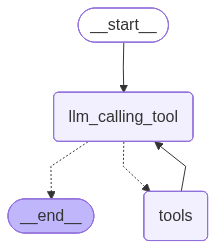

In [14]:
from langgraph.prebuilt import ToolNode, tools_condition
# build graph
graph = StateGraph(State)

# add node
graph.add_node('llm_calling_tool', llm_calling_tool)
graph.add_node("tools", ToolNode(tools))

# add edges
graph.add_edge(START, 'llm_calling_tool')
graph.add_conditional_edges(
    'llm_calling_tool',
    tools_condition
)
graph.add_edge('tools', 'llm_calling_tool') 

# compile graph
graph_builder = graph.compile()

# display the image
Image(graph_builder.get_graph().draw_mermaid_png())

In [15]:
from langchain_core.messages import HumanMessage

In [16]:
response = graph_builder.invoke({
    "messages": [HumanMessage(content="Tell me about Iran news in 2026")]
})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Tell me about Iran news in 2026
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_Kh2REBOs5baGdODocFh0X1vJ)
 Call ID: call_Kh2REBOs5baGdODocFh0X1vJ
  Args:
    query: Iran news 2026
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Iran Update, February 24, 2026 | ISW", "url": "https://understandingwar.org/research/middle-east/iran-update-february-24-2026/", "content": "Iran is continuing to prepare for a potential military conflict with the United States. Several unspecified Islamic Revolutionary Guards Corps (IRGC) Ground Forces units held an exercise on February 24 at the Madinah ol Munawarah Operational Base in Bandar Abbas, Hormozgan Province, and on unspecified Persian Gulf islands. Madinah ol Munawarah is located near the coast of the Strait of H

In [17]:
messages = graph_builder.invoke({"messages": HumanMessage(content="Tell me about iran new in 2026")})

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Tell me about iran new in 2026
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_etJC1k4gvdWdMzO86c67kAk9)
 Call ID: call_etJC1k4gvdWdMzO86c67kAk9
  Args:
    query: Iran news 2026
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Iran Update, February 24, 2026 | ISW", "url": "https://understandingwar.org/research/middle-east/iran-update-february-24-2026/", "content": "Iran is continuing to prepare for a potential military conflict with the United States. Several unspecified Islamic Revolutionary Guards Corps (IRGC) Ground Forces units held an exercise on February 24 at the Madinah ol Munawarah Operational Base in Bandar Abbas, Hormozgan Province, and on unspecified Persian Gulf islands. Madinah ol Munawarah is located near the coast of the Strait of Ho

In [18]:
messages = graph_builder.invoke({"messages": HumanMessage(content="Tell me about history of bangladesh in 1971")})

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Tell me about history of bangladesh in 1971
================================== Ai Message ==================================
Tool Calls:
  wikipedia (call_BIVLUj09y1cUumaYcfcmTdlm)
 Call ID: call_BIVLUj09y1cUumaYcfcmTdlm
  Args:
    query: History of Bangladesh in 1971
================================= Tool Message =================================
Name: wikipedia

Page: History of Bangladesh (1971–present)
Summary: The history of Bangladesh (1971–present) refers to the period after the independence of Bangladesh from Pakistan.
================================== Ai Message ==================================

The history of Bangladesh in 1971 is primarily marked by its struggle for independence from Pakistan. This struggle culminated in a war of liberation that resulted in the establishment of Bangladesh as an independent nation. 

Key events during this period include:

1. **Political Tensions:** Growing 

In [19]:
messages = graph_builder.invoke({"messages":"Tell me about history of bangladesh in 1971"})

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Tell me about history of bangladesh in 1971
================================== Ai Message ==================================
Tool Calls:
  wikipedia (call_vYWURSXmeulRcj6HVRFhy86p)
 Call ID: call_vYWURSXmeulRcj6HVRFhy86p
  Args:
    query: History of Bangladesh in 1971
================================= Tool Message =================================
Name: wikipedia

Page: History of Bangladesh (1971–present)
Summary: The history of Bangladesh (1971–present) refers to the period after the independence of Bangladesh from Pakistan.
================================== Ai Message ==================================
Tool Calls:
  wikipedia (call_IIn7InBCEOnkzvDwSJsjVE8o)
 Call ID: call_IIn7InBCEOnkzvDwSJsjVE8o
  Args:
    query: Bangladesh Liberation War 1971
================================= Tool Message =================================
Name: wikipedia

Page: Bangladesh Liberation War
Summary: The Bangladesh Lib

### Memory

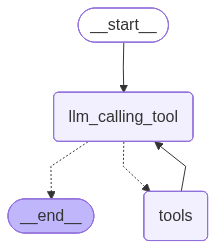

In [29]:
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

# build graph
graph = StateGraph(State)

# add node
graph.add_node('llm_calling_tool', llm_calling_tool)
graph.add_node("tools", ToolNode(tools))

# add edges
graph.add_edge(START, 'llm_calling_tool')
graph.add_conditional_edges(
    'llm_calling_tool',
    tools_condition
)
graph.add_edge('tools', 'llm_calling_tool') 

checkpointer = MemorySaver()

# compile graph
graph_builder = graph.compile(checkpointer=checkpointer)

# display the image
Image(graph_builder.get_graph().draw_mermaid_png())

In [33]:
configurable = {"configurable": {"thread_id": 1}}

messages = graph_builder.invoke({"messages":"what is 4 plus 10"}, config=configurable)

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

what is 4 plus 10
================================== Ai Message ==================================
Tool Calls:
  add (call_XCYzLHlclDAiqhXHmzcUxE7a)
 Call ID: call_XCYzLHlclDAiqhXHmzcUxE7a
  Args:
    a: 4
    b: 10
================================= Tool Message =================================
Name: add

14
================================== Ai Message ==================================

4 plus 10 equals 14.
================================ Human Message =================================

what is 4 plus 10
================================== Ai Message ==================================

4 plus 10 equals 14.


In [34]:
# configurable = {"configurable": {"thread_id": 2}}

messages = graph_builder.invoke({"messages":"add that number to 20"}, config=configurable)

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

what is 4 plus 10
================================== Ai Message ==================================
Tool Calls:
  add (call_XCYzLHlclDAiqhXHmzcUxE7a)
 Call ID: call_XCYzLHlclDAiqhXHmzcUxE7a
  Args:
    a: 4
    b: 10
================================= Tool Message =================================
Name: add

14
================================== Ai Message ==================================

4 plus 10 equals 14.
================================ Human Message =================================

what is 4 plus 10
================================== Ai Message ==================================

4 plus 10 equals 14.
================================ Human Message =================================

add that number to 20
================================== Ai Message ==================================
Tool Calls:
  add (call_Y9pFbaWCRyRtnTHLEE84YusD)
 Call ID: call_Y9pFbaWCRyRtnTHLEE84YusD
  Args:
    a: 14
    b: 2

In [35]:
messages = graph_builder.invoke({"messages":"that number divided by 2"}, config=configurable)

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

what is 4 plus 10
================================== Ai Message ==================================
Tool Calls:
  add (call_XCYzLHlclDAiqhXHmzcUxE7a)
 Call ID: call_XCYzLHlclDAiqhXHmzcUxE7a
  Args:
    a: 4
    b: 10
================================= Tool Message =================================
Name: add

14
================================== Ai Message ==================================

4 plus 10 equals 14.
================================ Human Message =================================

what is 4 plus 10
================================== Ai Message ==================================

4 plus 10 equals 14.
================================ Human Message =================================

add that number to 20
================================== Ai Message ==================================
Tool Calls:
  add (call_Y9pFbaWCRyRtnTHLEE84YusD)
 Call ID: call_Y9pFbaWCRyRtnTHLEE84YusD
  Args:
    a: 14
    b: 2